In [ ]:
import pandas as pd
from datetime import datetime
from IPython.display import display, HTML

In [ ]:
data = pd.read_csv("../Datasets/siri.20121106.csv", names = ['Timestamp','LineID','Direction','JourneyPatternID','TimeFrame','VehicleJourneyID','Operator','Congestion','Long','Lat','Delay','BlockID ','VehicleID','StopID','AtStop'])

/var/folders/h8/7s7s33b10fsdtf_d12tn7trm0000gn/T/marimo_11563/__marimo__cell_MJUe_.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../Datasets/siri.20121106.csv", names = ['Timestamp','LineID','Direction','JourneyPatternID','TimeFrame','VehicleJourneyID','Operator','Congestion','Long','Lat','Delay','BlockID ','VehicleID','StopID','AtStop'])


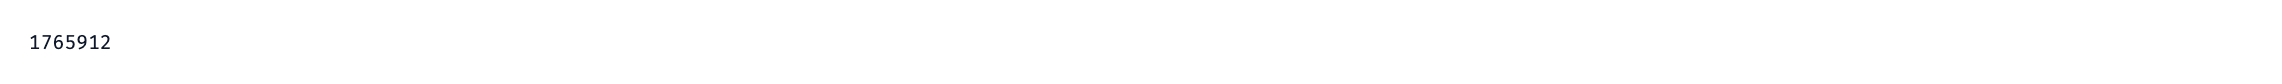

In [ ]:
data.shape[0]

In [ ]:
vehicles = data.VehicleID.unique()
print(len(vehicles))

835


In [ ]:
journeysDF = pd.DataFrame()
v = vehicles[0]
pings = data[data.VehicleID == v]
print(len(pings.VehicleJourneyID.unique()))
output = pings[['LineID', 'Direction', 'JourneyPatternID', 'VehicleJourneyID', 'StopID', 'AtStop', 'Timestamp']].copy()
output['TimeF'] = pings.Timestamp.apply(lambda x: datetime.utcfromtimestamp(x/1000000).strftime('%Y-%m-%d %H:%M:%S'))

28


/var/folders/h8/7s7s33b10fsdtf_d12tn7trm0000gn/T/marimo_11563/__marimo__cell_lEQa_.py:6: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  output['TimeF'] = pings.Timestamp.apply(lambda x: datetime.utcfromtimestamp(x/1000000).strftime('%Y-%m-%d %H:%M:%S'))


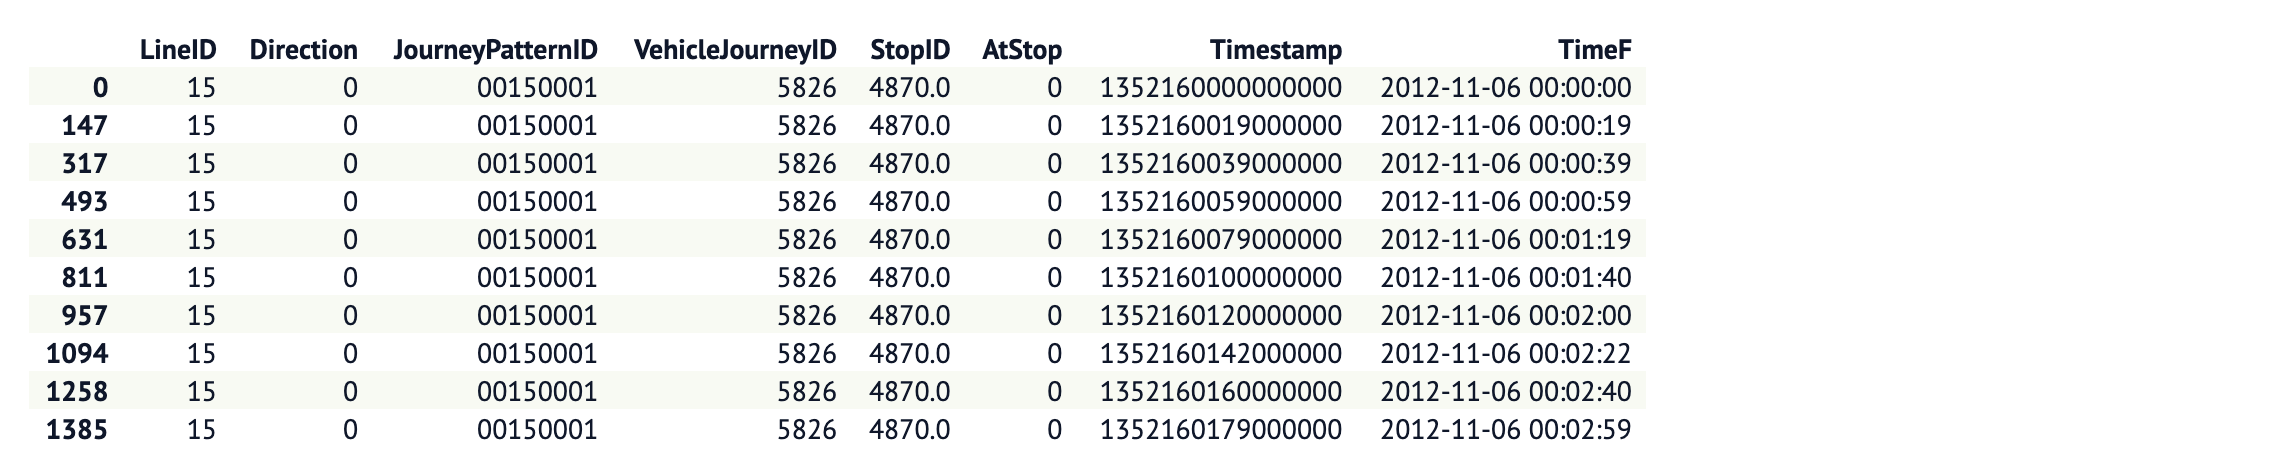

In [ ]:
display(HTML(output.head(10).to_html()))

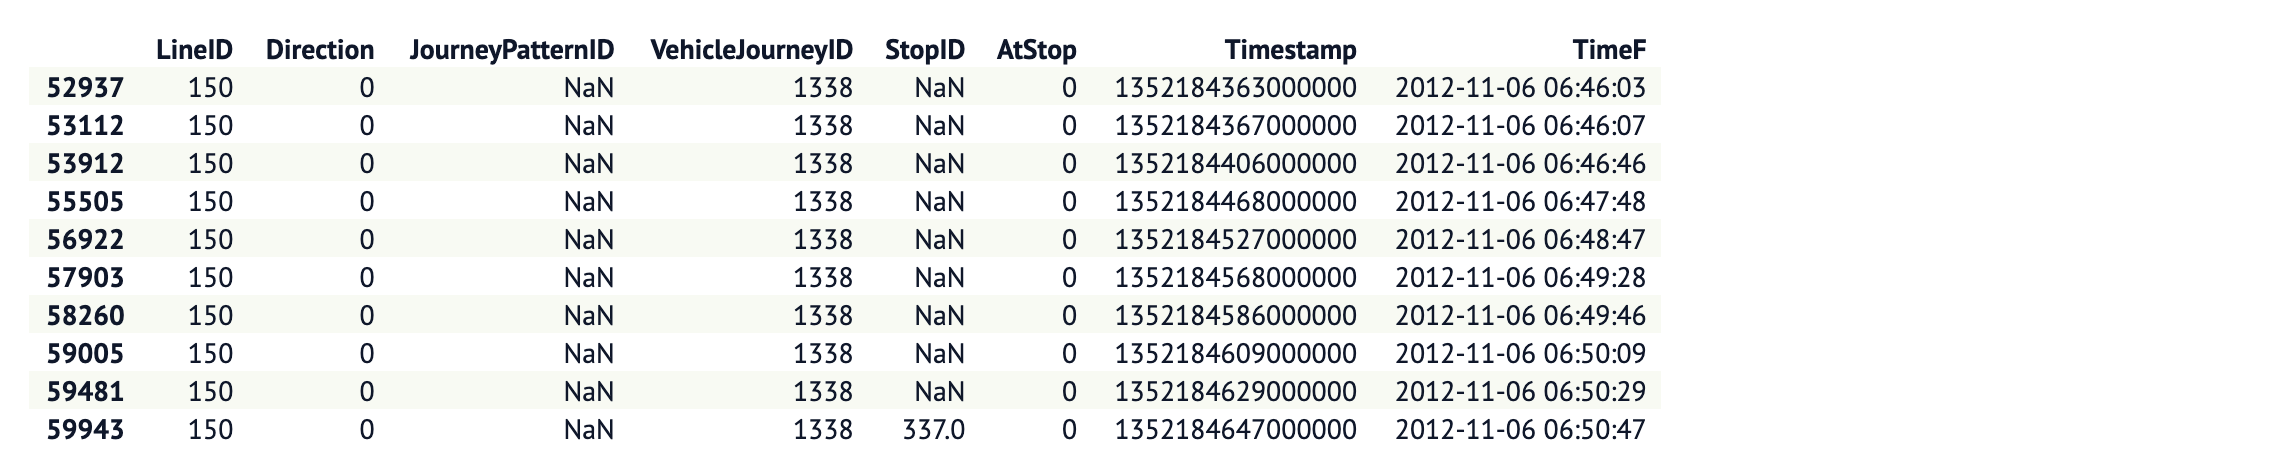

In [ ]:
journeys = output.VehicleJourneyID.unique()
display(HTML(output[output.VehicleJourneyID == journeys[1]].head(10).to_html()))

In [ ]:
o = pd.DataFrame(columns = ['JourneyID','Route', 'StartTime', 'Endtime', 'Duration'])
for j in journeys:
    journey = output[output.VehicleJourneyID == j]
    route = journey.iloc[0].LineID
    startTime = journey.iloc[0].TimeF
    endTime = journey.iloc[-1].TimeF
    x = journey.iloc[-1].Timestamp - journey.iloc[0].Timestamp 
    duration = datetime.utcfromtimestamp(x/1000000).strftime('%H:%M:%S')
    o = pd.concat([o, pd.DataFrame({'JourneyID': [j], 'Route': [route], 'StartTime': [startTime], 'Endtime': [endTime], 'Duration': [duration]})], ignore_index = True)

/var/folders/h8/7s7s33b10fsdtf_d12tn7trm0000gn/T/marimo_11563/__marimo__cell_SFPL_.py:8: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  duration = datetime.utcfromtimestamp(x/1000000).strftime('%H:%M:%S')


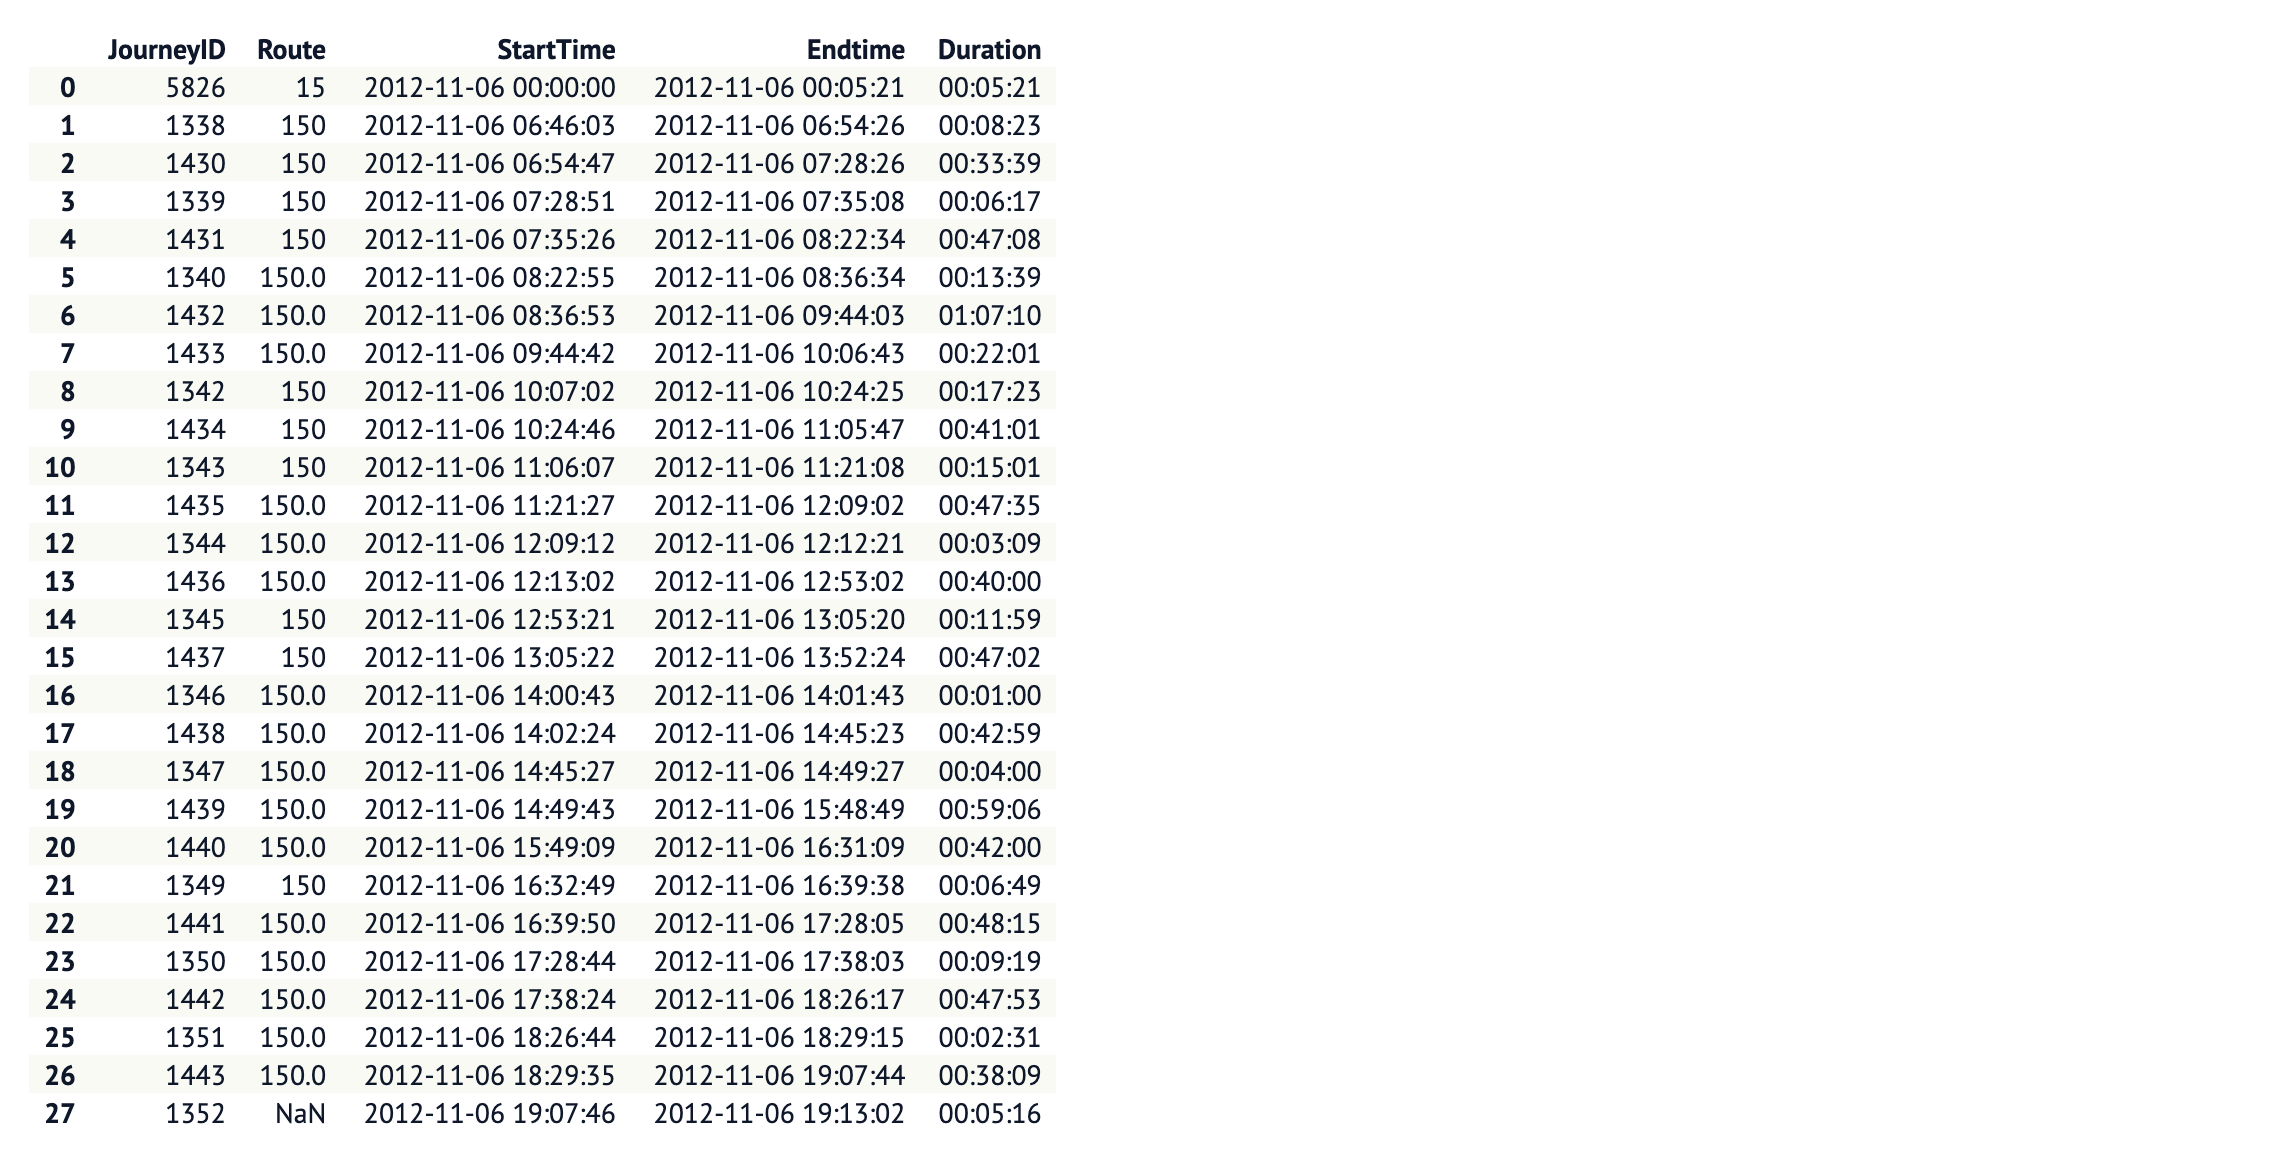

In [ ]:
display(HTML(o.to_html()))